# 데이터 전처리 결과 시각화

원본 데이터와 전처리된 train/val/test 데이터를 비교해 전처리가 의도대로 적용됐는지 확인한다.

확인 항목:
- 원본 데이터 기본 정보와 결측치
- train/val/test split 크기와 위험도 분포
- 원본 분포와 전처리 후 분포 비교
- `log1p` 변환 효과 확인
- `StandardScaler` 적용 후 평균/표준편차 확인
- 이진 컬럼 비율 비교
- 주요 컬럼 상관관계 확인

In [45]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'data').exists() and (candidate / 'artifacts').exists()
)

RAW_PATH = PROJECT_ROOT / 'data' / 'original_train_data' / 'seoul_road_points.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
TRAIN_PATH = PROCESSED_DIR / 'original_train_train_preprocessed.csv'
VAL_PATH = PROCESSED_DIR / 'original_train_val_preprocessed.csv'
TEST_PATH = PROCESSED_DIR / 'original_train_test_preprocessed.csv'
CONFIG_PATH = PROJECT_ROOT / 'artifacts' / 'preprocessors' / 'original_train_preprocess_config.json'

RANDOM_STATE = 42
SAMPLE_SIZE_FOR_PLOTS = 80_000
TOP_FEATURE_COUNT = 20

KOREAN_FONT_CANDIDATES = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',
    '/Library/Fonts/AppleGothic.ttf',
]

for font_path in KOREAN_FONT_CANDIDATES:
    if Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
        break
else:
    print('한글 폰트를 찾지 못했습니다. 그래프 한글이 깨지면 Noto Sans CJK 또는 NanumGothic을 설치하십시오.')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f"matplotlib font: {plt.rcParams['font.family']}")

PROJECT_ROOT: /home/huichan/SPARV/SilverWalk
matplotlib font: ['Noto Sans CJK JP']


## 1. 데이터 로드

원본 데이터와 전처리된 train/val/test split을 읽는다. 큰 데이터이므로 일부 그래프는 sample을 사용한다.

In [46]:
required_paths = [RAW_PATH, TRAIN_PATH, VAL_PATH, TEST_PATH, CONFIG_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError('\n'.join(str(path.relative_to(PROJECT_ROOT)) for path in missing_paths))

with CONFIG_PATH.open('r', encoding='utf-8') as file:
    config = json.load(file)

raw = pd.read_csv(RAW_PATH)
splits = {
    'train': pd.read_csv(TRAIN_PATH),
    'val': pd.read_csv(VAL_PATH),
    'test': pd.read_csv(TEST_PATH),
}
processed_all = pd.concat(
    [frame.assign(split=name) for name, frame in splits.items()],
    ignore_index=True,
)

feature_columns = config['feature_columns']
binary_columns = config['binary_columns']
raw_scale_columns = config['raw_scale_columns']
log_scale_columns = config['log_scale_columns']
scale_columns = config['scale_columns']

summary = pd.DataFrame([
    {
        'dataset': 'raw',
        'rows': len(raw),
        'columns': raw.shape[1],
        'missing_cells': int(raw.isna().sum().sum()),
        'duplicate_POINT_ID': int(raw['POINT_ID'].duplicated().sum()) if 'POINT_ID' in raw.columns else np.nan,
    },
    *[
        {
            'dataset': name,
            'rows': len(frame),
            'columns': frame.shape[1],
            'missing_cells': int(frame.isna().sum().sum()),
            'duplicate_POINT_ID': int(frame['POINT_ID'].duplicated().sum()) if 'POINT_ID' in frame.columns else np.nan,
        }
        for name, frame in splits.items()
    ],
])

display(summary)
print(f'feature columns: {len(feature_columns)}')
print(f'binary columns: {len(binary_columns)}')
print(f'log scale columns: {len(log_scale_columns)}')
print(f'scale columns: {len(scale_columns)}')

,dataset,rows,columns,missing_cells,duplicate_POINT_ID
0,raw,450663,106,0,0
1,train,315464,107,0,0
2,val,67599,107,0,0
3,test,67600,107,0,0


feature columns: 102
binary columns: 5
log scale columns: 96
scale columns: 97


## 2. 결측치 확인

원본 데이터와 전처리 데이터에서 결측치가 많은 컬럼을 확인한다.

In [47]:
def missing_summary(frame: pd.DataFrame, dataset_name: str, top_n: int = 20) -> pd.DataFrame:
    missing_count = frame.isna().sum()
    result = (
        missing_count[missing_count > 0]
        .sort_values(ascending=False)
        .head(top_n)
        .rename('missing_count')
        .reset_index()
        .rename(columns={'index': 'column'})
    )
    if result.empty:
        return pd.DataFrame([{'dataset': dataset_name, 'column': '-', 'missing_count': 0, 'missing_ratio': 0.0}])
    result.insert(0, 'dataset', dataset_name)
    result['missing_ratio'] = result['missing_count'] / len(frame)
    return result

missing_tables = [missing_summary(raw, 'raw')]
missing_tables.extend(missing_summary(frame, name) for name, frame in splits.items())
display(pd.concat(missing_tables, ignore_index=True))

,dataset,column,missing_count,missing_ratio
0,raw,-,0,0.0000
1,train,-,0,0.0000
2,val,-,0,0.0000
3,test,-,0,0.0000


## 3. Train / Val / Test 분할 확인

위험도 구간별로 split 비율이 비슷하게 유지되는지 확인한다.

,rows,ratio
split,,
train,315464,0.7000
val,67599,0.1500
test,67600,0.1500


split,test,train,val
risk_bin,,,
0,0.8006,0.8006,0.8006
0-1,0.0707,0.0707,0.0707
1-5,0.1039,0.1039,0.1039
20-50,0.0054,0.0054,0.0054
5-20,0.0178,0.0178,0.0178
50+,0.0016,0.0016,0.0016


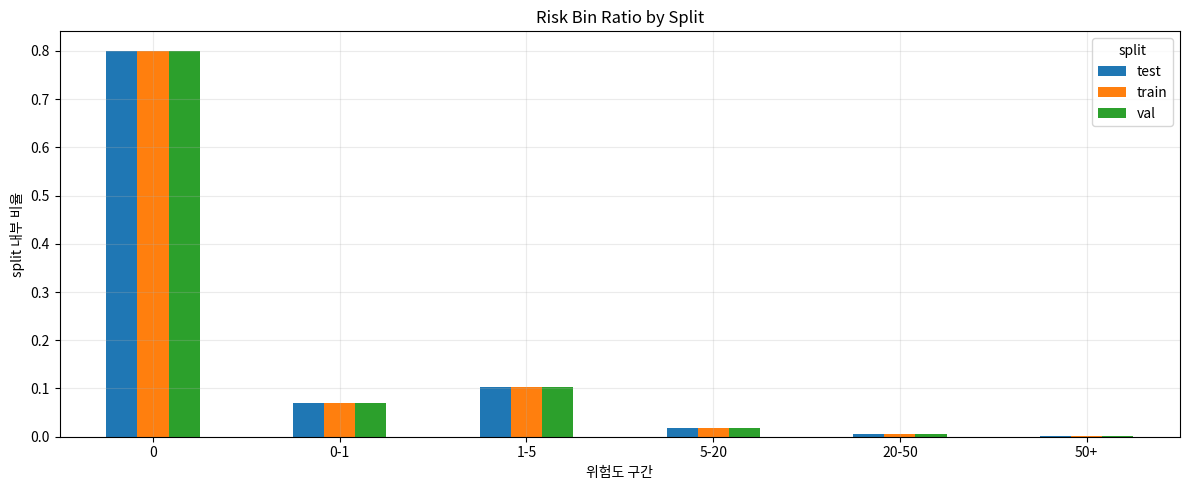

In [48]:
def risk_bin(series: pd.Series) -> pd.Series:
    return pd.cut(
        series,
        bins=[-np.inf, 0, 1, 5, 20, 50, np.inf],
        labels=['0', '0-1', '1-5', '5-20', '20-50', '50+'],
        include_lowest=True,
    ).astype(str)

split_counts = processed_all['split'].value_counts().reindex(['train', 'val', 'test']).to_frame('rows')
split_counts['ratio'] = split_counts['rows'] / split_counts['rows'].sum()
display(split_counts)

risk_dist = (
    processed_all.assign(risk_bin=risk_bin(processed_all['위험도']))
    .groupby(['split', 'risk_bin'])
    .size()
    .rename('count')
    .reset_index()
)
risk_dist['ratio_in_split'] = risk_dist['count'] / risk_dist.groupby('split')['count'].transform('sum')
display(risk_dist.pivot(index='risk_bin', columns='split', values='ratio_in_split').fillna(0))

pivot = risk_dist.pivot(index='risk_bin', columns='split', values='ratio_in_split').fillna(0).reindex(['0', '0-1', '1-5', '5-20', '20-50', '50+'])
ax = pivot.plot(kind='bar', figsize=(12, 5))
ax.set_title('Risk Bin Ratio by Split')
ax.set_xlabel('위험도 구간')
ax.set_ylabel('split 내부 비율')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. 위험도 분포

원본 위험도는 0이 많고 오른쪽 꼬리가 긴 분포이므로, 원본 scale과 `log1p` scale을 함께 확인한다.

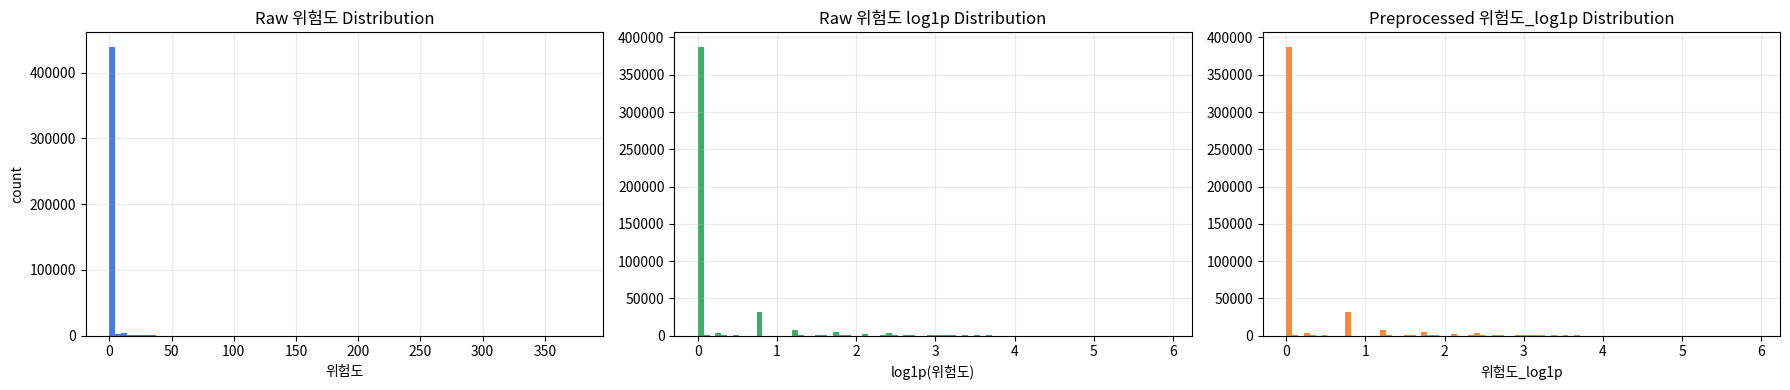

,raw_위험도,raw_log1p_위험도,processed_위험도_log1p
count,450663.0000,450663.0000,450663.0000
mean,0.6729,0.1763,0.1763
std,4.6049,0.5253,0.5253
min,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000
75%,0.0000,0.0000,0.0000
90%,1.1680,0.7738,0.7738
95%,2.4720,1.2447,1.2447
99%,12.7000,2.6174,2.6174
max,377.8720,5.9372,5.9372


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

raw['위험도'].hist(bins=80, ax=axes[0], color='#2563eb', alpha=0.85)
axes[0].set_title('Raw 위험도 Distribution')
axes[0].set_xlabel('위험도')
axes[0].set_ylabel('count')

np.log1p(raw['위험도'].clip(lower=0)).hist(bins=80, ax=axes[1], color='#16a34a', alpha=0.85)
axes[1].set_title('Raw 위험도 log1p Distribution')
axes[1].set_xlabel('log1p(위험도)')

processed_all['위험도_log1p'].hist(bins=80, ax=axes[2], color='#f97316', alpha=0.85)
axes[2].set_title('Preprocessed 위험도_log1p Distribution')
axes[2].set_xlabel('위험도_log1p')

plt.tight_layout()
plt.show()

risk_stats = pd.DataFrame({
    'raw_위험도': raw['위험도'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]),
    'raw_log1p_위험도': np.log1p(raw['위험도'].clip(lower=0)).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]),
    'processed_위험도_log1p': processed_all['위험도_log1p'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]),
})
display(risk_stats)

## 4-1. 위험도 컬럼 log 변환 전후 비교

정답 라벨인 `위험도`는 원본값을 보존하고, 모델 2 회귀 학습용으로 `위험도_log1p = log(1 + 위험도)`를 추가로 만든다.

아래 그래프는 같은 위험도 값을 원본 scale과 log1p scale에서 비교한다.

/tmp/ipykernel_73931/2255402439.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(


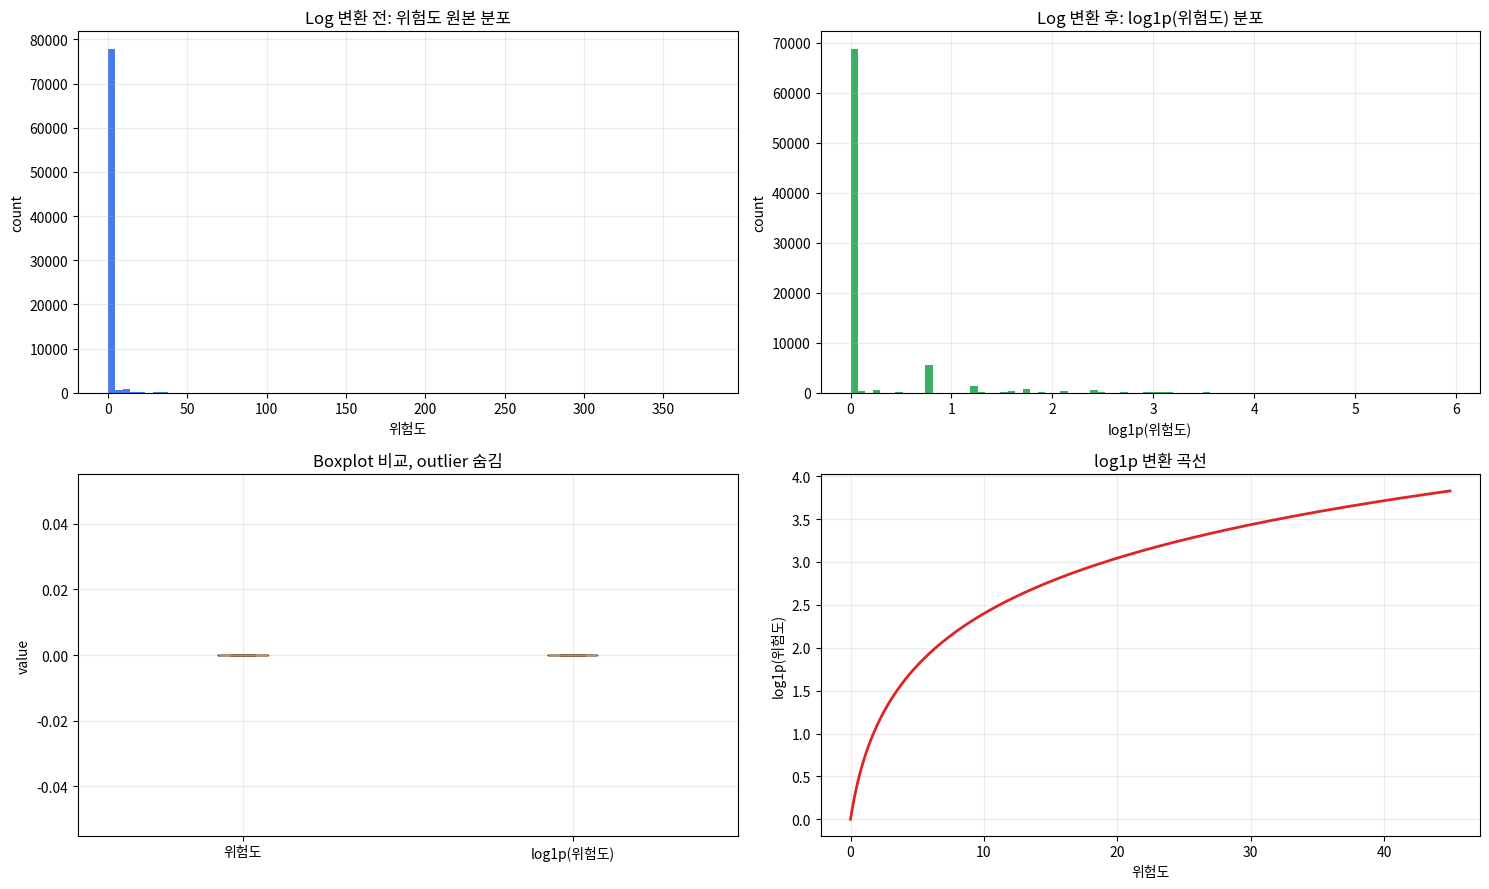

,위험도,log1p(위험도)
count,450663.0000,450663.0000
mean,0.6729,0.1763
std,4.6049,0.5253
min,0.0000,0.0000
50%,0.0000,0.0000
75%,0.0000,0.0000
90%,1.1680,0.7738
95%,2.4720,1.2447
99%,12.7000,2.6174
max,377.8720,5.9372


In [50]:
risk_compare = pd.DataFrame({
    '위험도': raw['위험도'].clip(lower=0),
})
risk_compare['위험도_log1p'] = np.log1p(risk_compare['위험도'])
risk_compare_sample = risk_compare.sample(
    min(len(risk_compare), SAMPLE_SIZE_FOR_PLOTS),
    random_state=RANDOM_STATE,
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].hist(risk_compare_sample['위험도'], bins=80, color='#2563eb', alpha=0.85)
axes[0, 0].set_title('Log 변환 전: 위험도 원본 분포')
axes[0, 0].set_xlabel('위험도')
axes[0, 0].set_ylabel('count')

axes[0, 1].hist(risk_compare_sample['위험도_log1p'], bins=80, color='#16a34a', alpha=0.85)
axes[0, 1].set_title('Log 변환 후: log1p(위험도) 분포')
axes[0, 1].set_xlabel('log1p(위험도)')
axes[0, 1].set_ylabel('count')

axes[1, 0].boxplot(
    [risk_compare_sample['위험도'], risk_compare_sample['위험도_log1p']],
    labels=['위험도', 'log1p(위험도)'],
    showfliers=False,
)
axes[1, 0].set_title('Boxplot 비교, outlier 숨김')
axes[1, 0].set_ylabel('value')

positive_risk = risk_compare[risk_compare['위험도'] > 0]
if positive_risk.empty:
    axes[1, 1].text(0.5, 0.5, '위험도 > 0 데이터가 없습니다.', ha='center', va='center')
else:
    x_max = positive_risk['위험도'].quantile(0.99)
    x_values = np.linspace(0, x_max, 300)
    axes[1, 1].plot(x_values, np.log1p(x_values), color='#dc2626', linewidth=2)
    axes[1, 1].set_title('log1p 변환 곡선')
    axes[1, 1].set_xlabel('위험도')
    axes[1, 1].set_ylabel('log1p(위험도)')

plt.tight_layout()
plt.show()

risk_compare_stats = pd.DataFrame({
    '위험도': risk_compare['위험도'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]),
    'log1p(위험도)': risk_compare['위험도_log1p'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]),
})
display(risk_compare_stats)

## 5. 원본 분포 vs 전처리 후 분포

주요 수치 컬럼을 대상으로 원본 값과 전처리 후 값을 비교한다.

전처리 후 값은 `log1p`와 `StandardScaler`가 적용되어 평균 0 부근, 표준편차 1 부근으로 변환된다.

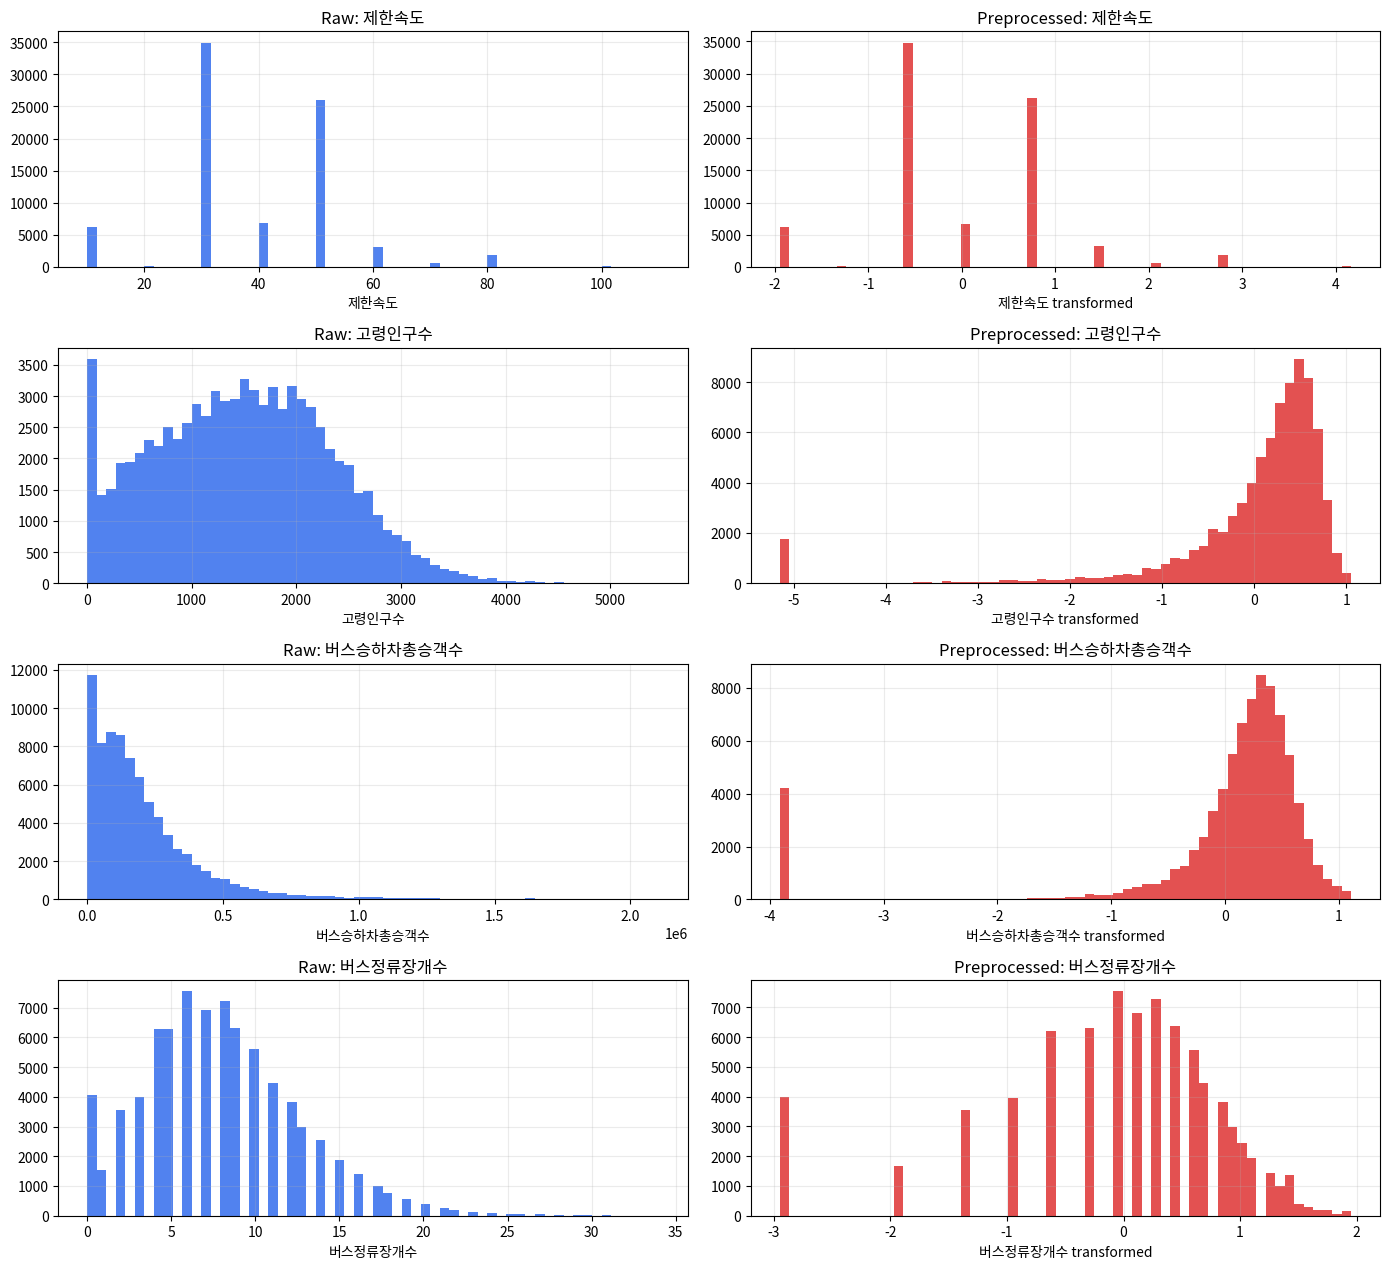

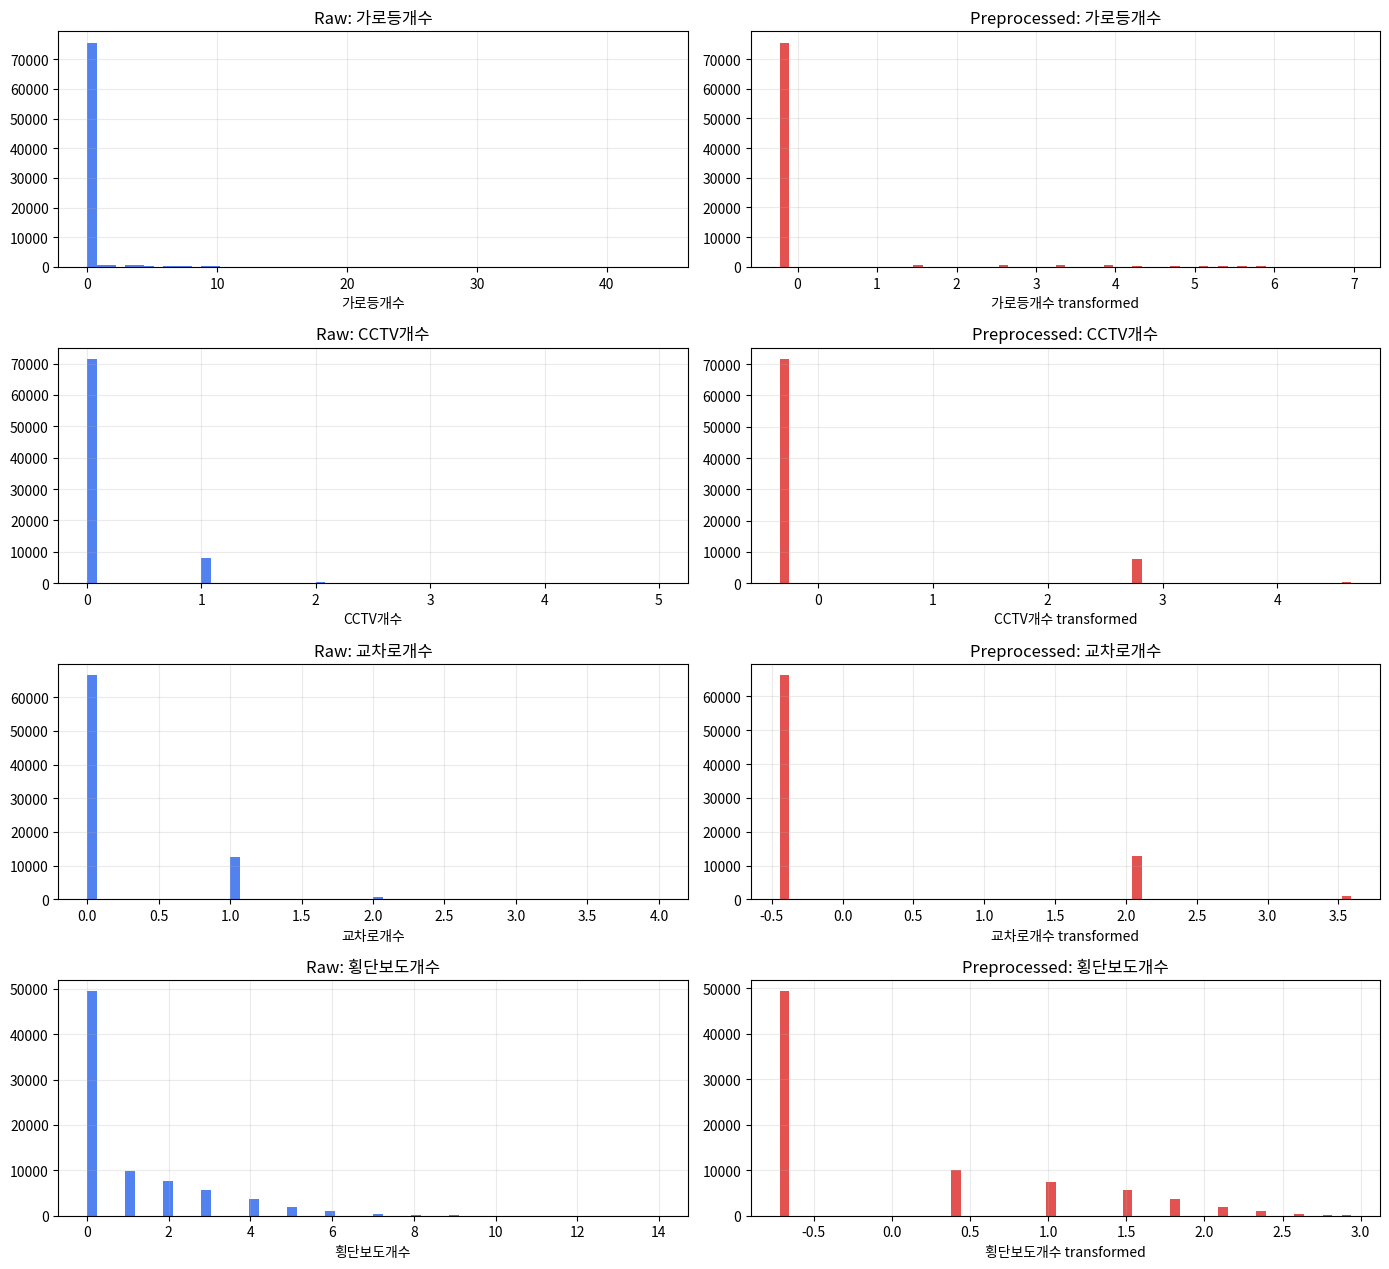

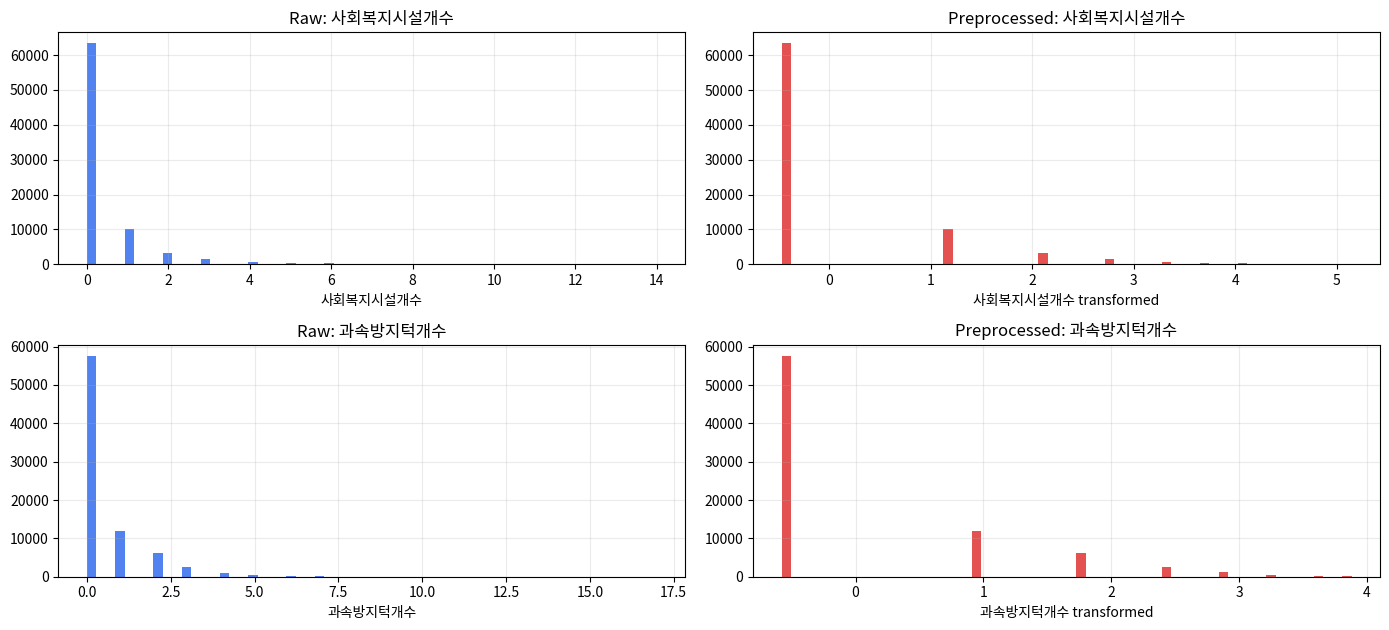

In [51]:
preferred_columns = [
    '제한속도',
    '고령인구수',
    '버스승하차총승객수',
    '버스정류장개수',
    '가로등개수',
    'CCTV개수',
    '교차로개수',
    '횡단보도개수',
    '사회복지시설개수',
    '과속방지턱개수',
]
comparison_columns = [column for column in preferred_columns if column in raw.columns and column in processed_all.columns]

raw_plot = raw.sample(min(len(raw), SAMPLE_SIZE_FOR_PLOTS), random_state=RANDOM_STATE)
processed_plot = processed_all.sample(min(len(processed_all), SAMPLE_SIZE_FOR_PLOTS), random_state=RANDOM_STATE)

for start in range(0, len(comparison_columns), 4):
    columns = comparison_columns[start:start + 4]
    fig, axes = plt.subplots(len(columns), 2, figsize=(14, 3.2 * len(columns)))
    if len(columns) == 1:
        axes = np.array([axes])

    for row_idx, column in enumerate(columns):
        raw_values = raw_plot[column].dropna()
        processed_values = processed_plot[column].dropna()

        axes[row_idx, 0].hist(raw_values, bins=60, color='#2563eb', alpha=0.8)
        axes[row_idx, 0].set_title(f'Raw: {column}')
        axes[row_idx, 0].set_xlabel(column)

        axes[row_idx, 1].hist(processed_values, bins=60, color='#dc2626', alpha=0.8)
        axes[row_idx, 1].set_title(f'Preprocessed: {column}')
        axes[row_idx, 1].set_xlabel(f'{column} transformed')

    plt.tight_layout()
    plt.show()

## 6. `log1p` 변환 효과

`log_scale_columns`는 원본에서 값의 범위가 큰 컬럼이다. `log1p`를 적용하면 큰 값의 영향이 줄어든다.

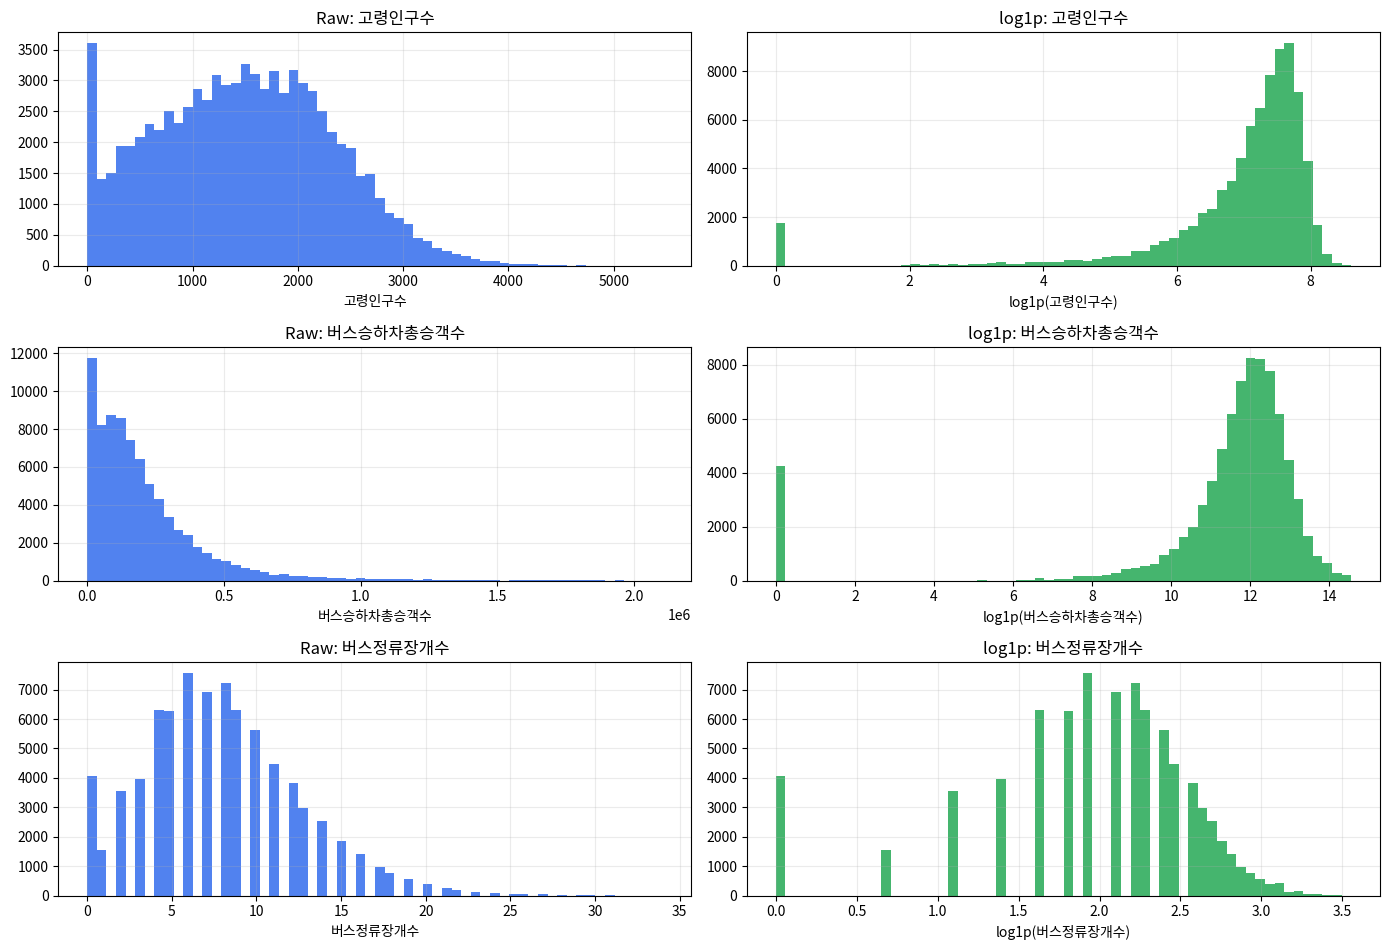

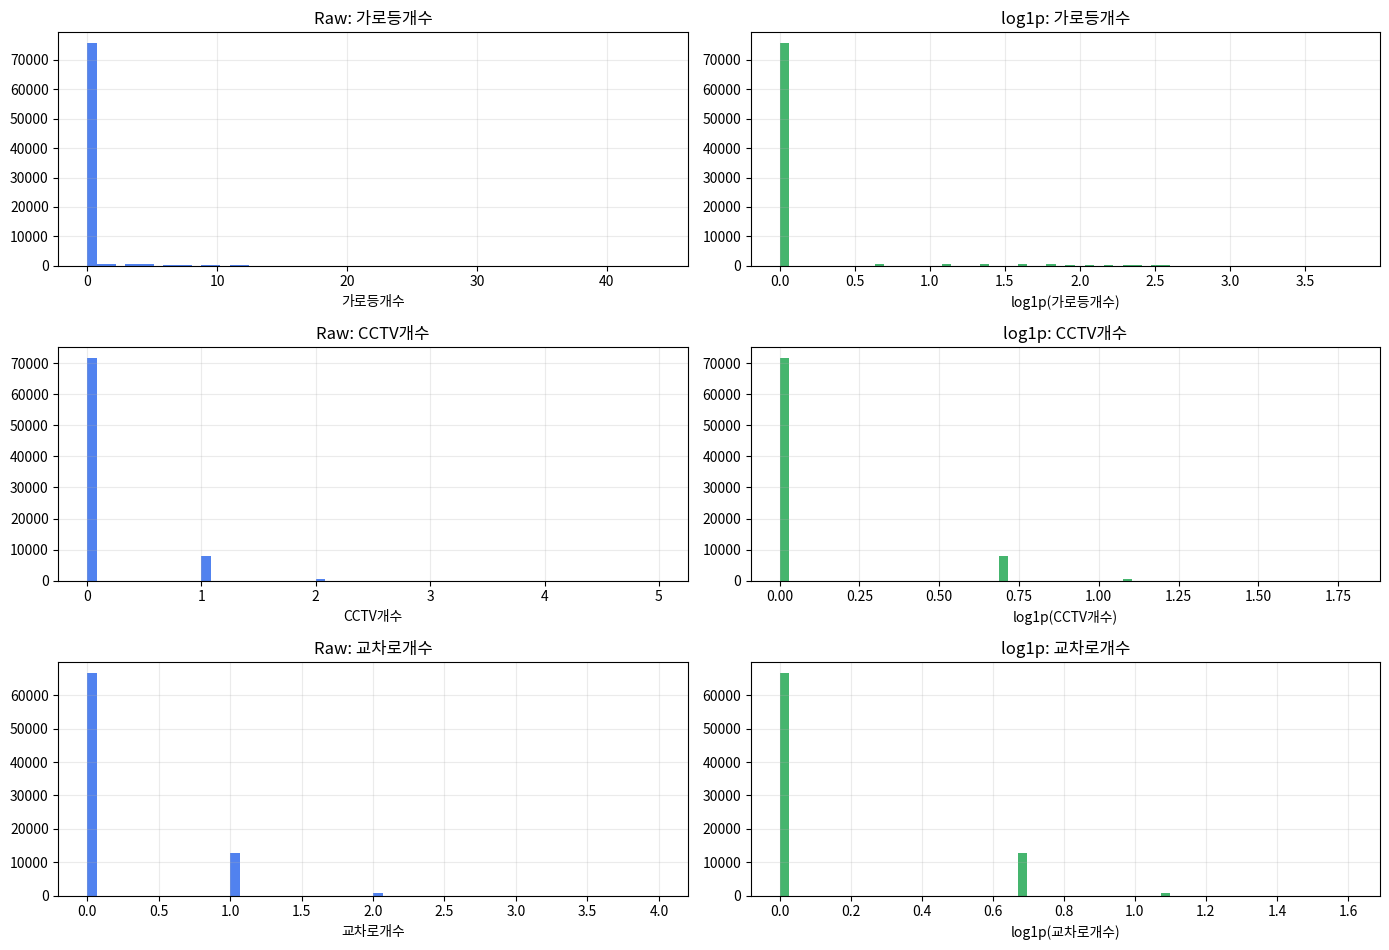

In [52]:
log_effect_columns = [column for column in comparison_columns if column in log_scale_columns][:6]

for start in range(0, len(log_effect_columns), 3):
    columns = log_effect_columns[start:start + 3]
    fig, axes = plt.subplots(len(columns), 2, figsize=(14, 3.2 * len(columns)))
    if len(columns) == 1:
        axes = np.array([axes])

    for row_idx, column in enumerate(columns):
        values = raw_plot[column].dropna().clip(lower=0)
        axes[row_idx, 0].hist(values, bins=60, color='#2563eb', alpha=0.8)
        axes[row_idx, 0].set_title(f'Raw: {column}')
        axes[row_idx, 0].set_xlabel(column)

        axes[row_idx, 1].hist(np.log1p(values), bins=60, color='#16a34a', alpha=0.8)
        axes[row_idx, 1].set_title(f'log1p: {column}')
        axes[row_idx, 1].set_xlabel(f'log1p({column})')

    plt.tight_layout()
    plt.show()

## 7. 표준화 결과 확인

`StandardScaler`는 train split 기준으로 fit된다. 따라서 train split의 스케일 대상 컬럼은 평균 0, 표준편차 1에 가까워야 한다.

,mean,std,min,max,abs_mean
고령인구수,0.0000,1.0000,-5.1517,1.0571,0.0000
버스정류장개수,-0.0000,1.0000,-2.9499,1.9545,0.0000
소매_가전·통신 소매,0.0000,1.0000,-1.5515,4.4266,0.0000
버스승하차총승객수,0.0000,1.0000,-3.9162,1.1131,0.0000
과학·기술_기술 서비스,0.0000,1.0000,-1.3766,3.2956,0.0000
시설관리·임대_청소·방제,0.0000,1.0000,-1.7042,2.5384,0.0000
수리·개인,0.0000,1.0000,-2.9975,1.7184,0.0000
소매_철물·건설자재 소매,-0.0000,1.0000,-1.4667,2.6754,0.0000
예술·스포츠_스포츠 서비스,0.0000,1.0000,-1.7631,2.0972,0.0000
수리·개인_기타 가정용품 수리,0.0000,1.0000,-1.5238,4.2293,0.0000


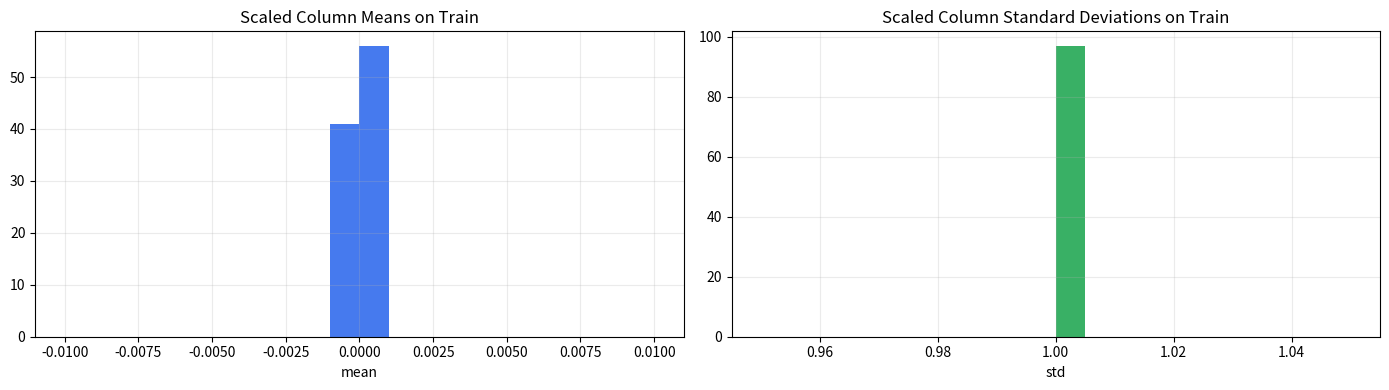

In [53]:
scaled_check = splits['train'][scale_columns].agg(['mean', 'std', 'min', 'max']).T
scaled_check['abs_mean'] = scaled_check['mean'].abs()
scaled_check = scaled_check.sort_values('abs_mean', ascending=False)
display(scaled_check.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(scaled_check['mean'], bins=20, range=(-0.01, 0.01), color='#2563eb', alpha=0.85)
axes[0].set_title('Scaled Column Means on Train')
axes[0].set_xlabel('mean')

axes[1].hist(scaled_check['std'], bins=20, range=(0.95, 1.05), color='#16a34a', alpha=0.85)
axes[1].set_title('Scaled Column Standard Deviations on Train')
axes[1].set_xlabel('std')

plt.tight_layout()
plt.show()

## 8. 이진 컬럼 분포

이진 컬럼은 스케일링하지 않고 0/1 값으로 유지된다.

,dataset,column,rows,positive_ratio,zero_ratio,missing_ratio,unique_values
0,raw,전통시장여부,450663,0.0921,0.9079,0.0000,"[0, 1]"
1,raw,보행자우선도로여부,450663,0.0129,0.9871,0.0000,"[0, 1]"
2,raw,노인장애인보호구역여부,450663,0.1402,0.8598,0.0000,"[0, 1]"
3,raw,횡단보도예고표시여부,450663,0.2598,0.7402,0.0000,"[0, 1]"
4,raw,신호등설치여부,450663,0.1946,0.8054,0.0000,"[0, 1]"
5,train,전통시장여부,315464,0.0922,0.9078,0.0000,"[0, 1]"
6,train,보행자우선도로여부,315464,0.0129,0.9871,0.0000,"[0, 1]"
7,train,노인장애인보호구역여부,315464,0.1400,0.8600,0.0000,"[0, 1]"
8,train,횡단보도예고표시여부,315464,0.2589,0.7411,0.0000,"[0, 1]"
9,train,신호등설치여부,315464,0.1946,0.8054,0.0000,"[0, 1]"


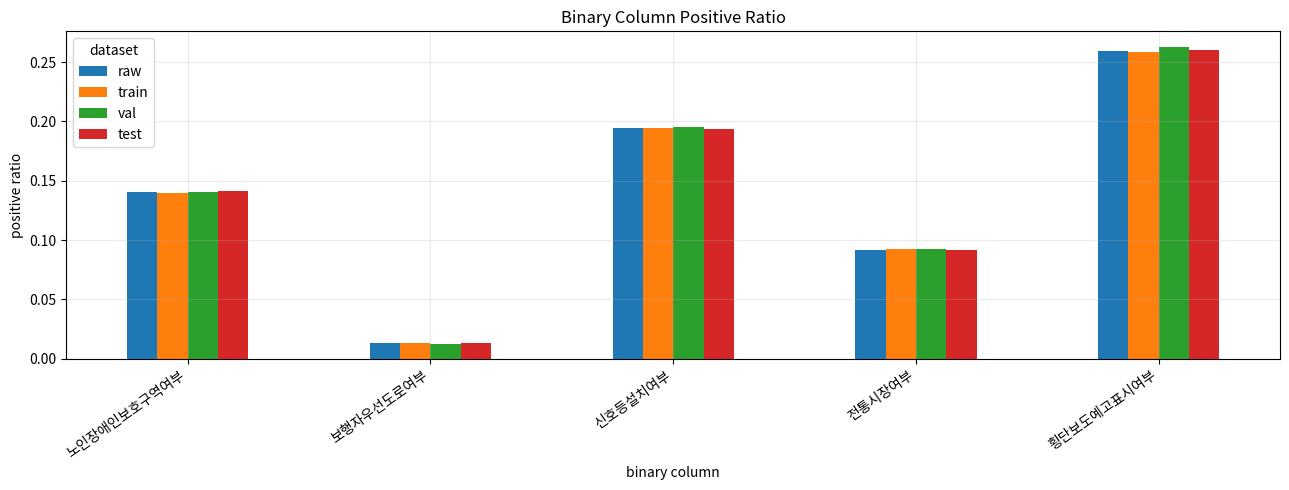

In [54]:
binary_summary_rows = []
for dataset_name, frame in [('raw', raw), *splits.items()]:
    for column in binary_columns:
        if column not in frame.columns:
            continue
        values = frame[column].dropna()
        binary_summary_rows.append({
            'dataset': dataset_name,
            'column': column,
            'rows': len(frame),
            'positive_ratio': float((values == 1).mean()) if len(values) else np.nan,
            'zero_ratio': float((values == 0).mean()) if len(values) else np.nan,
            'missing_ratio': float(frame[column].isna().mean()),
            'unique_values': sorted(frame[column].dropna().unique().tolist()),
        })

binary_summary = pd.DataFrame(binary_summary_rows)
display(binary_summary)

pivot = binary_summary.pivot(index='column', columns='dataset', values='positive_ratio')
ordered_columns = [name for name in ['raw', 'train', 'val', 'test'] if name in pivot.columns]
ax = pivot[ordered_columns].plot(kind='bar', figsize=(13, 5))
ax.set_title('Binary Column Positive Ratio')
ax.set_xlabel('binary column')
ax.set_ylabel('positive ratio')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 9. 전처리 전후 boxplot 비교

큰 이상값이 있는 컬럼은 전처리 후 분포가 더 안정적인 범위로 들어오는지 확인한다.

/tmp/ipykernel_73931/1348520488.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(raw_box, labels=box_columns, showfliers=False)
/tmp/ipykernel_73931/1348520488.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(processed_box, labels=box_columns, showfliers=False)


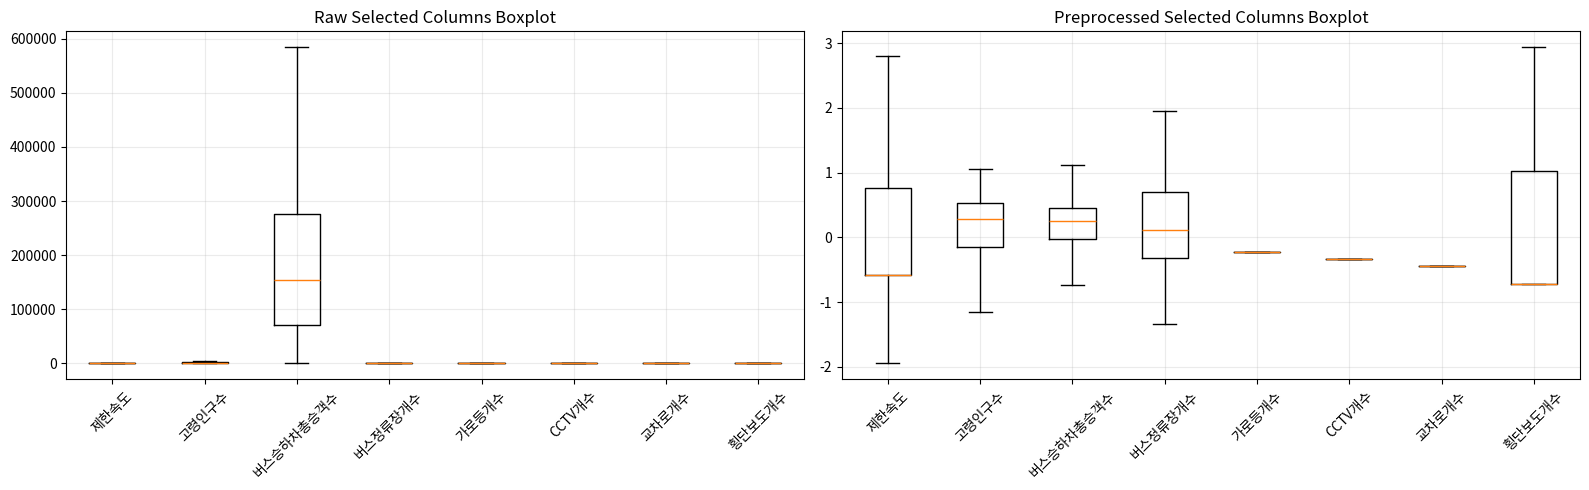

In [55]:
box_columns = comparison_columns[:8]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
raw_box = [raw_plot[column].dropna().to_numpy() for column in box_columns]
processed_box = [processed_plot[column].dropna().to_numpy() for column in box_columns]

axes[0].boxplot(raw_box, labels=box_columns, showfliers=False)
axes[0].set_title('Raw Selected Columns Boxplot')
axes[0].tick_params(axis='x', rotation=45)

axes[1].boxplot(processed_box, labels=box_columns, showfliers=False)
axes[1].set_title('Preprocessed Selected Columns Boxplot')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. 주요 feature와 위험도 관계

상관계수 절대값이 큰 feature를 확인한다. 전처리된 feature 기준으로 보며, 선형 상관만 보여주므로 모델 중요도와 동일하지는 않다.

,feature,corr_with_위험도_log1p
0,횡단보도개수,0.2837
1,신호등설치여부,0.2585
2,교차로개수,0.2524
3,소매_식료품 소매,0.1794
4,보건의료_의원,0.1662
5,보건의료,0.1659
6,횡단보도예고표시여부,0.1630
7,소매_의약·화장품 소매,0.1608
8,예술·스포츠_유원지·오락,0.1600
9,소매,0.1564


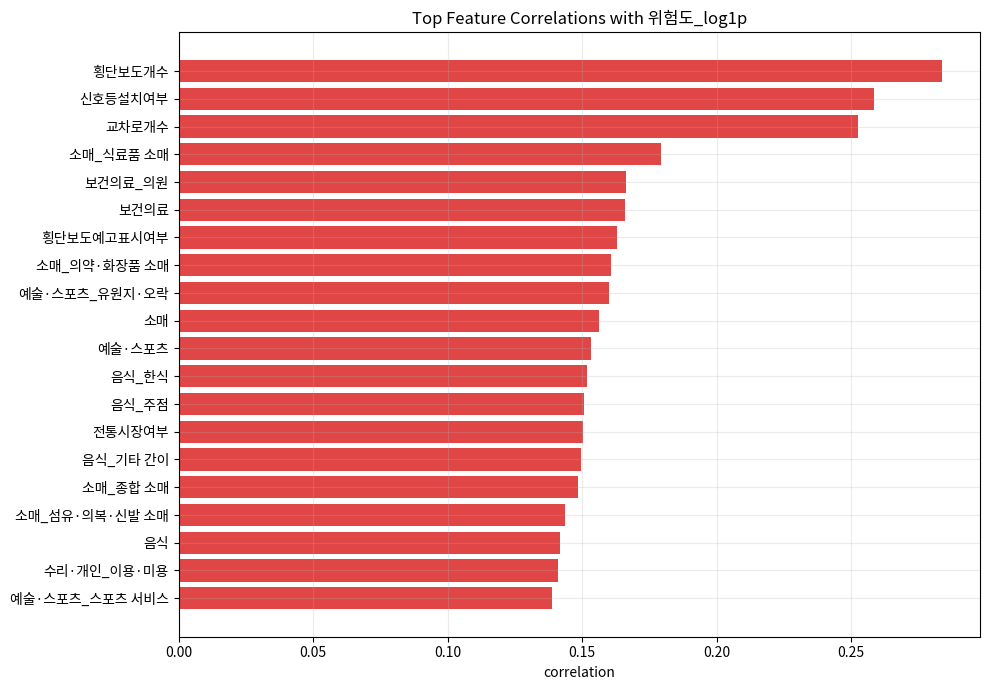

In [56]:
corr_frame = processed_all[feature_columns + ['위험도_log1p']].sample(
    min(len(processed_all), SAMPLE_SIZE_FOR_PLOTS),
    random_state=RANDOM_STATE,
)
correlations = (
    corr_frame.corr(numeric_only=True)['위험도_log1p']
    .drop('위험도_log1p')
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

top_corr = correlations.head(TOP_FEATURE_COUNT).reset_index()
top_corr.columns = ['feature', 'corr_with_위험도_log1p']
display(top_corr)

plot_corr = top_corr.sort_values('corr_with_위험도_log1p')
fig, ax = plt.subplots(figsize=(10, 7))
colors = np.where(plot_corr['corr_with_위험도_log1p'] >= 0, '#dc2626', '#2563eb')
ax.barh(plot_corr['feature'], plot_corr['corr_with_위험도_log1p'], color=colors, alpha=0.85)
ax.set_title('Top Feature Correlations with 위험도_log1p')
ax.set_xlabel('correlation')
plt.tight_layout()
plt.show()

## 11. 주요 feature 간 상관관계 heatmap

상위 상관 feature들끼리 중복 정보가 많은지 확인한다.

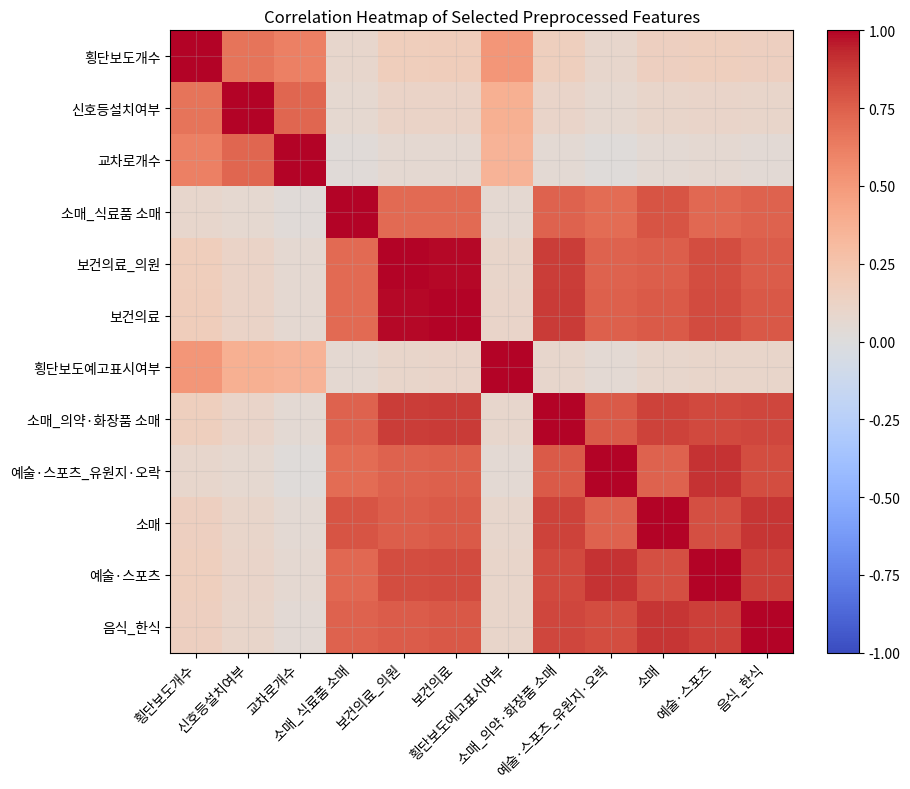

In [57]:
heatmap_columns = top_corr['feature'].head(12).tolist()
heatmap_data = corr_frame[heatmap_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(heatmap_columns)))
ax.set_yticks(np.arange(len(heatmap_columns)))
ax.set_xticklabels(heatmap_columns, rotation=45, ha='right')
ax.set_yticklabels(heatmap_columns)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation Heatmap of Selected Preprocessed Features')
plt.tight_layout()
plt.show()

## 12. 위치 기반 위험도 분포 확인

위도/경도는 모델 입력에서 제외되지만 지도 표시용 key로 유지된다. 여기서는 공간적으로 위험도가 어떻게 분포하는지만 확인한다.

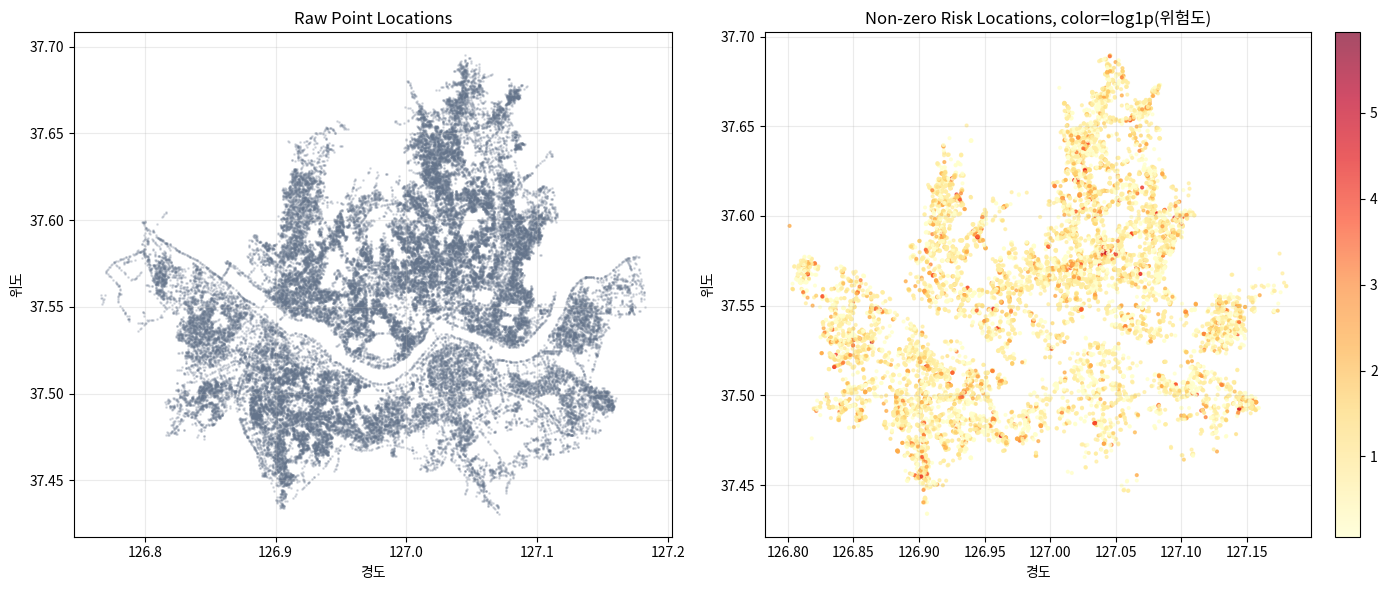

In [58]:
if {'경도', '위도', '위험도'}.issubset(raw.columns):
    map_sample = raw.sample(min(len(raw), 60_000), random_state=RANDOM_STATE)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].scatter(map_sample['경도'], map_sample['위도'], s=1, alpha=0.2, color='#64748b')
    axes[0].set_title('Raw Point Locations')
    axes[0].set_xlabel('경도')
    axes[0].set_ylabel('위도')

    nonzero = map_sample[map_sample['위험도'] > 0]
    scatter = axes[1].scatter(
        nonzero['경도'],
        nonzero['위도'],
        c=np.log1p(nonzero['위험도']),
        s=4,
        alpha=0.7,
        cmap='YlOrRd',
    )
    axes[1].set_title('Non-zero Risk Locations, color=log1p(위험도)')
    axes[1].set_xlabel('경도')
    axes[1].set_ylabel('위도')
    fig.colorbar(scatter, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
else:
    print('위치 시각화에 필요한 경도/위도/위험도 컬럼이 없습니다.')

## 13. 전처리 설정 요약

전처리 config에 저장된 컬럼 분류와 기준값 일부를 확인한다.

In [59]:
config_summary = pd.DataFrame([
    {'구분': '모델 제외 컬럼', '개수': len(config['excluded_model_columns']), '예시': ', '.join(config['excluded_model_columns'])},
    {'구분': '모델 feature 컬럼', '개수': len(feature_columns), '예시': ', '.join(feature_columns[:8])},
    {'구분': '이진 컬럼', '개수': len(binary_columns), '예시': ', '.join(binary_columns)},
    {'구분': 'log1p + StandardScaler 컬럼', '개수': len(log_scale_columns), '예시': ', '.join(log_scale_columns[:8])},
    {'구분': 'StandardScaler 컬럼', '개수': len(scale_columns), '예시': ', '.join(scale_columns[:8])},
])
display(config_summary)

imputation_preview = pd.DataFrame({
    'median': pd.Series(config['medians']),
    'clip_upper_bound': pd.Series(config['clip_upper_bounds']),
}).head(20)
display(imputation_preview)

display(pd.Series(config['binary_modes'], name='binary_mode').to_frame())

,구분,개수,예시
0,모델 제외 컬럼,4,"POINT_ID, 위도, 경도, 위험도"
1,모델 feature 컬럼,102,"제한속도, 고령인구수, 사회복지시설개수, 전통시장여부, 버스정류장개수, 버스승하차총..."
2,이진 컬럼,5,"전통시장여부, 보행자우선도로여부, 노인장애인보호구역여부, 횡단보도예고표시여부, 신호..."
3,log1p + StandardScaler 컬럼,96,"고령인구수, 사회복지시설개수, 버스정류장개수, 버스승하차총승객수, 지하철역개수, 가..."
4,StandardScaler 컬럼,97,"제한속도, 고령인구수, 사회복지시설개수, 버스정류장개수, 버스승하차총승객수, 지하철..."


,median,clip_upper_bound
제한속도,30.0000,100.0000
고령인구수,1488.0000,4240.1480
사회복지시설개수,0.0000,10.0000
버스정류장개수,7.0000,27.0000
버스승하차총승객수,154011.0000,1814857.0000
지하철역개수,0.0000,3.0000
가로등개수,0.0000,16.0000
CCTV개수,0.0000,2.0000
공영주차장개수,0.0000,7.0000
과속방지턱개수,0.0000,7.0000


,binary_mode
전통시장여부,0
보행자우선도로여부,0
노인장애인보호구역여부,0
횡단보도예고표시여부,0
신호등설치여부,0


## 14. 위험도 0 / 위험도 양수 포인트 개수

원본 데이터와 train/val/test split에서 `위험도 = 0` 포인트와 `위험도 > 0` 포인트가 각각 몇 개인지 확인한다.

,dataset,total_count,위험도=0_count,위험도>0_count,위험도=0_ratio,위험도>0_ratio
0,raw,450663,360787,89876,0.8006,0.1994
1,train,315464,252551,62913,0.8006,0.1994
2,val,67599,54118,13481,0.8006,0.1994
3,test,67600,54118,13482,0.8006,0.1994


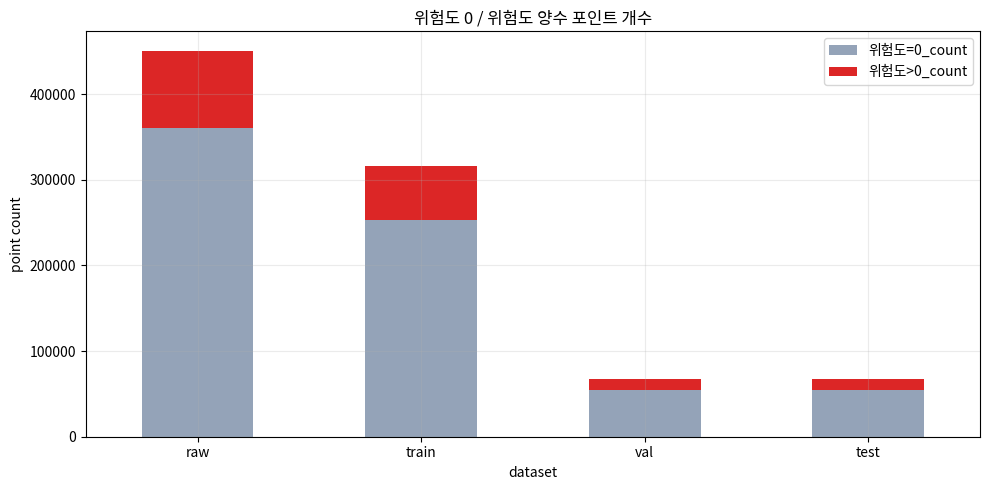

In [60]:
risk_zero_rows = []
for dataset_name, frame in [('raw', raw), *splits.items()]:
    zero_count = int((frame['위험도'] == 0).sum())
    positive_count = int((frame['위험도'] > 0).sum())
    total_count = len(frame)
    risk_zero_rows.append({
        'dataset': dataset_name,
        'total_count': total_count,
        '위험도=0_count': zero_count,
        '위험도>0_count': positive_count,
        '위험도=0_ratio': zero_count / total_count if total_count else np.nan,
        '위험도>0_ratio': positive_count / total_count if total_count else np.nan,
    })

risk_zero_summary = pd.DataFrame(risk_zero_rows)
display(risk_zero_summary)

plot_data = risk_zero_summary.set_index('dataset')[['위험도=0_count', '위험도>0_count']]
ax = plot_data.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#94a3b8', '#dc2626'])
ax.set_title('위험도 0 / 위험도 양수 포인트 개수')
ax.set_xlabel('dataset')
ax.set_ylabel('point count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. 위험도 양수 데이터 분포

`위험도 > 0`인 포인트만 따로 필터링해 위험도 크기 분포를 확인한다. 모델 2는 이 데이터만 사용해 위험도 크기를 학습한다.

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
dataset,,,,,,,,,,,
raw,89876.0000,3.3740,9.8597,0.0680,0.0680,1.1680,2.4720,7.2120,12.7000,44.9440,377.8720
train,62913.0000,3.3786,9.8642,0.0680,0.0680,1.1680,2.4720,7.2120,13.7200,44.8168,317.1600
val,13481.0000,3.3980,10.4342,0.0680,0.0680,1.1680,2.4720,7.2120,12.7000,42.3360,377.8720
test,13482.0000,3.3285,9.2277,0.0680,0.0680,1.1680,2.4720,7.2120,12.7000,45.2160,221.3760


/tmp/ipykernel_73931/1842157938.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(box_data, labels=['train', 'val', 'test'], showfliers=False)
/tmp/ipykernel_73931/1842157938.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(log_box_data, labels=['train', 'val', 'test'], showfliers=False)


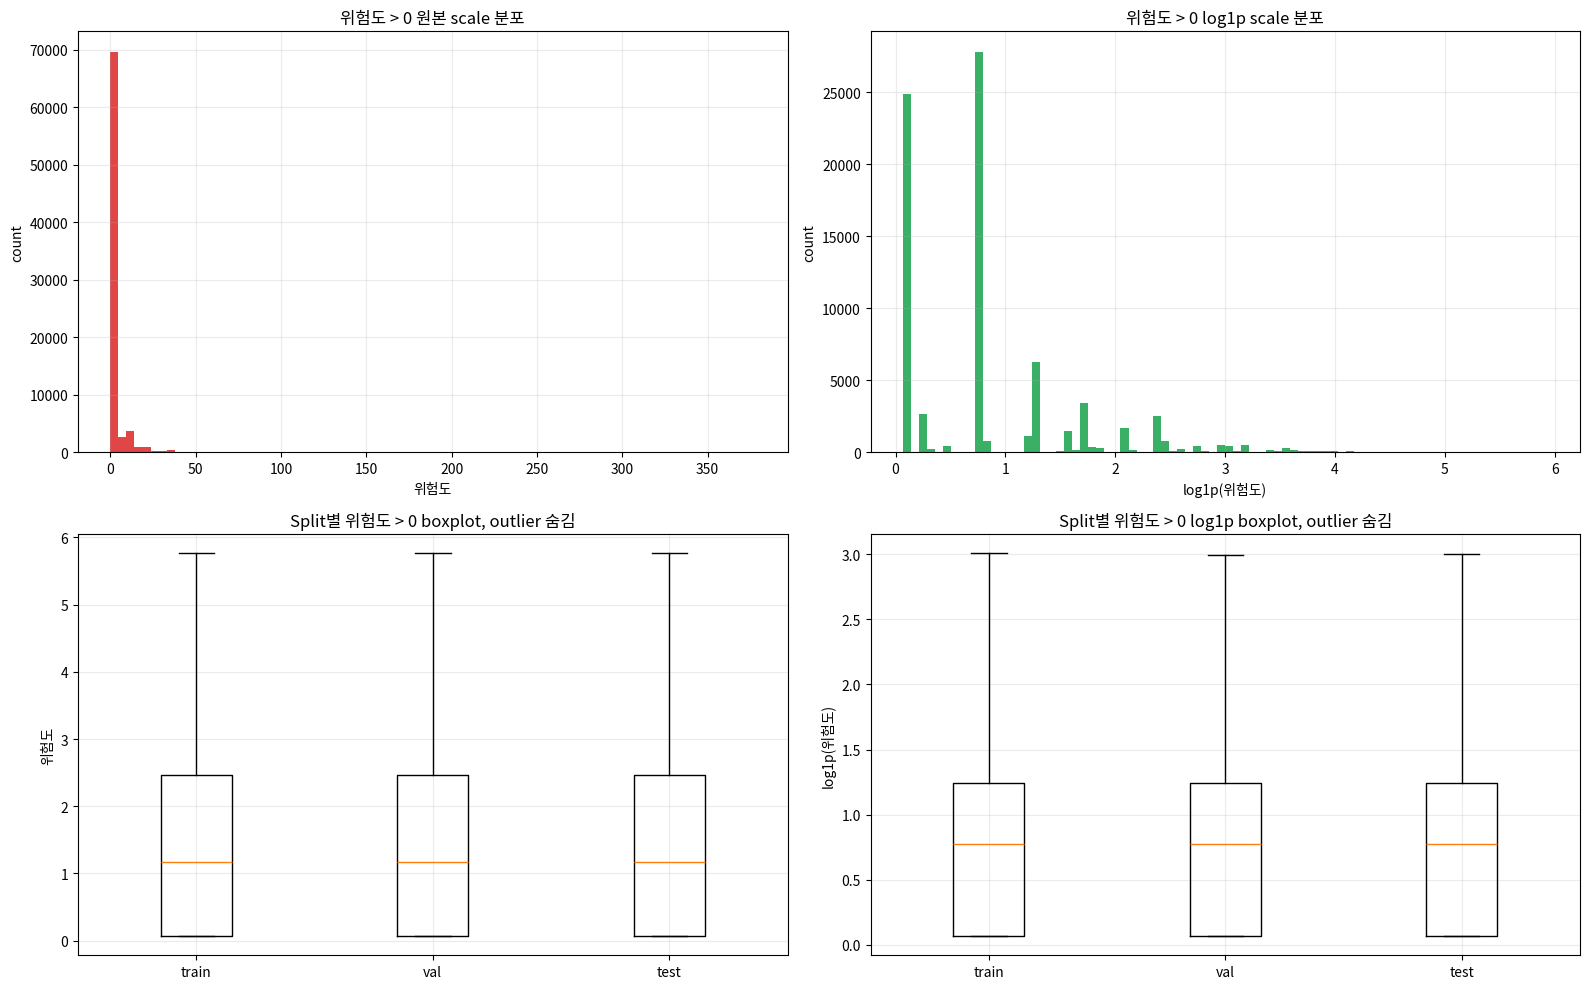

/tmp/ipykernel_73931/1842157938.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['dataset', '위험도구간'])


,dataset,위험도구간,count,ratio_in_positive
0,raw,0-1,31847,0.3543
1,raw,1-5,46839,0.5212
2,raw,5-20,8038,0.0894
3,raw,20-50,2451,0.0273
4,raw,50+,701,0.0078
5,test,0-1,4777,0.3543
6,test,1-5,7026,0.5211
7,test,5-20,1206,0.0895
8,test,20-50,368,0.0273
9,test,50+,105,0.0078


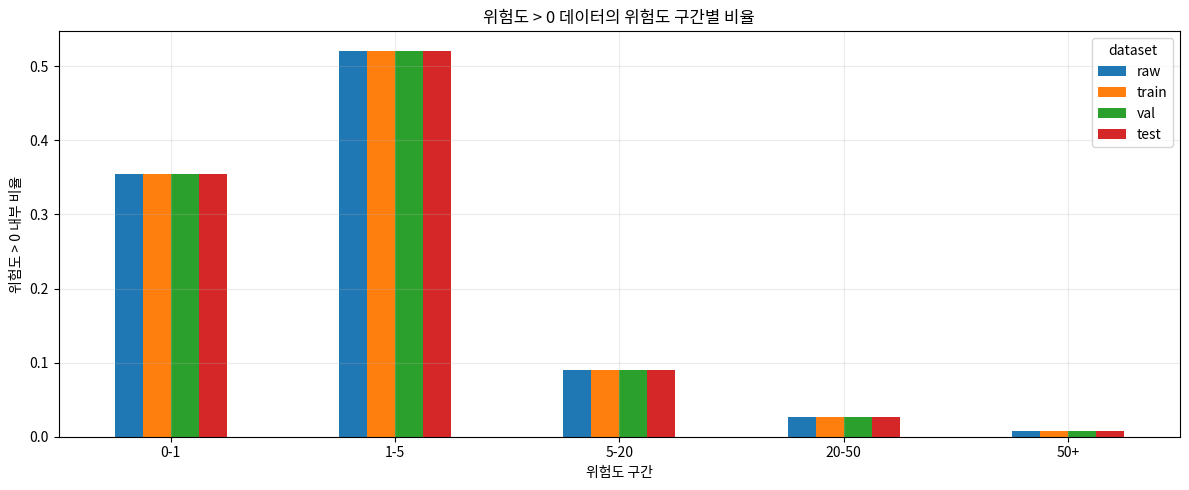

In [61]:
positive_risk_frames = []
for dataset_name, frame in [('raw', raw), *splits.items()]:
    positive = frame[frame['위험도'] > 0].copy()
    positive['dataset'] = dataset_name
    positive['위험도_log1p_calc'] = np.log1p(positive['위험도'].clip(lower=0))
    positive_risk_frames.append(positive[['dataset', '위험도', '위험도_log1p_calc']])

positive_risk_all = pd.concat(positive_risk_frames, ignore_index=True)

positive_summary = (
    positive_risk_all
    .groupby('dataset')['위험도']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .reindex(['raw', 'train', 'val', 'test'])
)
display(positive_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

raw_positive = positive_risk_all[positive_risk_all['dataset'] == 'raw']
raw_positive_sample = raw_positive.sample(
    min(len(raw_positive), SAMPLE_SIZE_FOR_PLOTS),
    random_state=RANDOM_STATE,
)

axes[0, 0].hist(raw_positive_sample['위험도'], bins=80, color='#dc2626', alpha=0.85)
axes[0, 0].set_title('위험도 > 0 원본 scale 분포')
axes[0, 0].set_xlabel('위험도')
axes[0, 0].set_ylabel('count')

axes[0, 1].hist(raw_positive_sample['위험도_log1p_calc'], bins=80, color='#16a34a', alpha=0.85)
axes[0, 1].set_title('위험도 > 0 log1p scale 분포')
axes[0, 1].set_xlabel('log1p(위험도)')
axes[0, 1].set_ylabel('count')

box_data = [
    positive_risk_all.loc[positive_risk_all['dataset'] == dataset, '위험도'].to_numpy()
    for dataset in ['train', 'val', 'test']
]
axes[1, 0].boxplot(box_data, labels=['train', 'val', 'test'], showfliers=False)
axes[1, 0].set_title('Split별 위험도 > 0 boxplot, outlier 숨김')
axes[1, 0].set_ylabel('위험도')

log_box_data = [
    positive_risk_all.loc[positive_risk_all['dataset'] == dataset, '위험도_log1p_calc'].to_numpy()
    for dataset in ['train', 'val', 'test']
]
axes[1, 1].boxplot(log_box_data, labels=['train', 'val', 'test'], showfliers=False)
axes[1, 1].set_title('Split별 위험도 > 0 log1p boxplot, outlier 숨김')
axes[1, 1].set_ylabel('log1p(위험도)')

plt.tight_layout()
plt.show()

positive_bins = pd.cut(
    positive_risk_all['위험도'],
    bins=[0, 1, 5, 20, 50, np.inf],
    labels=['0-1', '1-5', '5-20', '20-50', '50+'],
    include_lowest=True,
)
positive_bin_table = (
    positive_risk_all.assign(위험도구간=positive_bins)
    .groupby(['dataset', '위험도구간'])
    .size()
    .rename('count')
    .reset_index()
)
positive_bin_table['ratio_in_positive'] = (
    positive_bin_table['count'] / positive_bin_table.groupby('dataset')['count'].transform('sum')
)
display(positive_bin_table)

pivot = (
    positive_bin_table
    .pivot(index='위험도구간', columns='dataset', values='ratio_in_positive')
    .fillna(0)
    .reindex(['0-1', '1-5', '5-20', '20-50', '50+'])
)
ax = pivot[[column for column in ['raw', 'train', 'val', 'test'] if column in pivot.columns]].plot(
    kind='bar',
    figsize=(12, 5),
)
ax.set_title('위험도 > 0 데이터의 위험도 구간별 비율')
ax.set_xlabel('위험도 구간')
ax.set_ylabel('위험도 > 0 내부 비율')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()